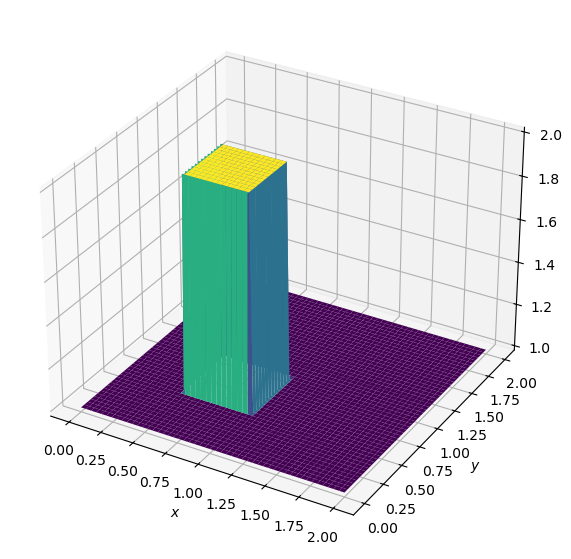

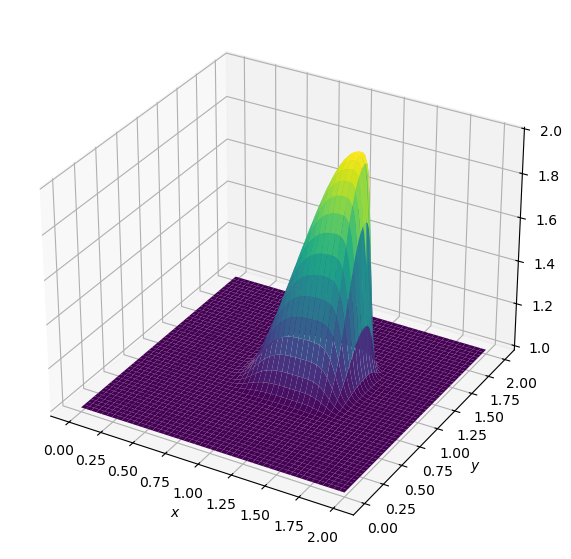

In [12]:
# Step 6: 2-D Convection

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot, cm
import numpy

nx = 101
ny = 101
nt = 80
c = 1
dx = 2 / (nx -1)
dy = 2 / (ny -1)
sigma =0.2
dt = sigma * dx   # ?why

x = numpy.linspace(0, 2, nx)
y = numpy.linspace(0, 2, ny)

u = numpy.ones((ny,nx))
v = numpy.ones((ny,nx))
un = numpy.ones((ny,nx))
vv = numpy.ones((ny,nx))

u[int(0.5 / dy) : int(1 / dy + 1), int(0.5 / dx) : int(1 / dx + 1)] = 2
v[int(0.5 / dy) : int(1 / dy + 1), int(0.5 / dx) : int(1 / dx + 1)] = 2

fig, ax = pyplot.subplots(figsize=(11, 7), dpi=100, subplot_kw=dict(projection='3d'))
X, Y = numpy.meshgrid(x, y)

ax.plot_surface(X, Y, u, cmap=cm.viridis, rstride=2, cstride=2) # 颜色映射（colormap）,rstride 行采样步长, cstride 列采样步长， 
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');

for n in range(nt + 1):
    un = u.copy()
    vn = v.copy()
    u[1:, 1:] = (un[1: ,1:] - 
                 (un[1: ,1:] * c * dt / dx * (un[1: ,1:] - un[1:, :-1])) - 
                 vn[1: ,1:] * c * dt / dy * (un[1: ,1:] - un[:-1, 1:]))
    v[1:, 1:] = (vn[1: ,1:] - 
                 (un[1: ,1:] * c * dt / dx * (vn[1: ,1:] - vn[1:, :-1])) - 
                 vn[1: ,1:] * c * dt / dy * (vn[1: ,1:] - vn[:-1, 1:]))

    u[0, :] = 1         # u[j, i] 下边界
    u[-1, :] = 1
    u[:, 0] = 1
    u[:, -1] = 1

    v[0, :] = 1
    v[-1, :] = 1
    v[:, 0] = 1
    v[:, -1] = 1

fig, ax = pyplot.subplots(figsize=(11, 7), dpi=100, subplot_kw=dict(projection='3d'))
X, Y = numpy.meshgrid(x, y)

ax.plot_surface(X, Y, u, cmap=cm.viridis, rstride=2, cstride=2) # 颜色映射（colormap）,rstride 行采样步长, cstride 列采样步长， 
ax.set_xlabel('$x$')
ax.set_ylabel('$y$');